# Versatile slide reader for TIFF-like image files

Built upon `tifffile` and `tensorstore`, `ezslide` provides slide reader for lazily accessing TIFF-like image files including `.svs`, `.ndpi`, `.ome.tif` and more. The API is more intuitive compared to `tifffile`, and compared to other readers from `openslide` or `wsidata`, `ezslide` runs faster and is more memory efficient when repeatedly accessing areas from WSIs.

The following section shows how to read an example WSI from the internet and access the underlying image data:

In [1]:
!curl -o "../sample_images/example_he_wsi.svs" "https://openslide.cs.cmu.edu/download/openslide-testdata/Aperio/JP2K-33003-1.svs"

  % Total    % Received % Xferd  

Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0


  0 60.8M    0 36415    0     0   223k      0  0:04:38 --:--:--  0:04:38  222k


 10 60.8M   10 6687k    0     0  5790k      0  0:00:10  0:00:01  0:00:09 5785k


 21 60.8M   21 13.2M    0     0  6323k      0  0:00:09  0:00:02  0:00:07 6321k

...


 63 60.8M   63 38.6M    0     0  5524k      0  0:00:11  0:00:07  0:00:04 5180k


 71 60.8M   71 43.5M    0     0  5472k      0  0:00:11  0:00:08  0:00:03 5087k


 80 60.8M   80 48.7M    0     0  5453k      0  0:00:11  0:00:09  0:00:02 5076k


 89 60.8M   89 54.4M    0     0  5495k      0  0:00:11  0:00:10  0:00:01 5296k


100 60.8M  100 60.8M    0     0  5626k      0  0:00:11  0:00:11 --:--:-- 5667k


According to Tagged Image File Format (TIFF) specification, an image consists of multiple series (explain what this means to layman?), and in the case of an `.svs` image, the first series "Baseline" contains the full resolution image, and the other series contains thumbnail or the slide label.

In [2]:
import ezslide

he_wsi = ezslide.open_slide("../sample_images/example_he_wsi.svs")
he_wsi

TiffFile (svs) from ../sample_images/example_he_wsi.svs with 4 image series:  
  Series 'Baseline' with 3 levels 
  Series 'Thumbnail' with 1 levels 
  Series 'Label' with 1 levels 
  Series 'Macro' with 1 levels

Each series can be intuitively accessed (compared to using tifffile, show API for comparison?) by indexing the WSI handle. An image series can either be a flat or a pyramidal image, and in the latter case consists of multiple successively more low-resolution levels. 

In [3]:
he_wsi.series

[Image 'Baseline' 
 Data type: uint8 
 Axes order: YXS 
 Pyramidal with 3 levels: 
   Level 0, data shape: (17497, 15374, 3), chunk shape: (256, 256, 3) 
   Level 1, data shape: (4374, 3843, 3), chunk shape: (256, 256, 3) 
   Level 2, data shape: (2187, 1921, 3), chunk shape: (256, 256, 3),
 Image 'Thumbnail' 
 Data type: uint8 
 Axes order: YXS 
 Data shape: (768, 674, 3),
 Image 'Label' 
 Data type: uint8 
 Axes order: YXS 
 Data shape: (422, 415, 3),
 Image 'Macro' 
 Data type: uint8 
 Axes order: YXS 
 Data shape: (421, 1280, 3)]

In [4]:
he_wsi[0]

Image 'Baseline' 
Data type: uint8 
Axes order: YXS 
Pyramidal with 3 levels: 
  Level 0, data shape: (17497, 15374, 3), chunk shape: (256, 256, 3) 
  Level 1, data shape: (4374, 3843, 3), chunk shape: (256, 256, 3) 
  Level 2, data shape: (2187, 1921, 3), chunk shape: (256, 256, 3)

Each level can be accessed by indexing just as before, note, this gives only a view (hence is very fast) of the underlying data without actually reading any image data into memory.

In [5]:
he_wsi[0].levels

[Pyramid level 0,
 dask.array<from-zarr, shape=(17497, 15374, 3), dtype=uint8, chunksize=(256, 256, 3), chunktype=numpy.ndarray>,
 Pyramid level 1,
 dask.array<from-zarr, shape=(4374, 3843, 3), dtype=uint8, chunksize=(256, 256, 3), chunktype=numpy.ndarray>,
 Pyramid level 2,
 dask.array<from-zarr, shape=(2187, 1921, 3), dtype=uint8, chunksize=(256, 256, 3), chunktype=numpy.ndarray>]

In [6]:
he_wsi[0][0]

Pyramid level 0,
dask.array<from-zarr, shape=(17497, 15374, 3), dtype=uint8, chunksize=(256, 256, 3), chunktype=numpy.ndarray>

The image levels can be further indexed to produce lazy views over image data that can also be instantiated when needed

In [7]:
he_wsi[0][2][0:1000, 0:1000]

<TensorStoreArray shape=(1000, 1000, 3) uint8 chunks=(256, 256, 3) lazy driver=virtual_chunked>

(1000, 1000, 3) <class 'numpy.ndarray'>


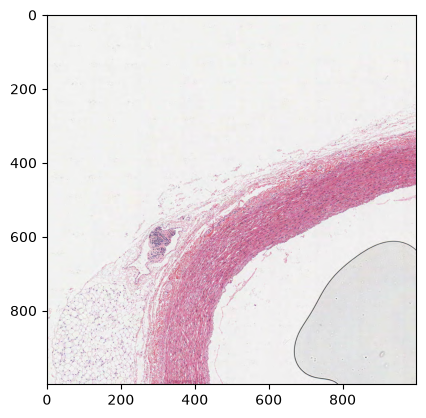

In [8]:
from matplotlib import pyplot as plt
import numpy as np

actual_data = np.array(he_wsi[0][2][0:1000, 0:1000])
print(actual_data.shape, type(actual_data))

# or...some functions can fetch the data as a numpy array directly
plt.imshow(he_wsi[0][2][0:1000, 0:1000])

## Reading vsi images

Sometimes my colleague will share vsi images obtained with Olympus scanners with me, and neither `tifffile` nor `openslide` can open them. It turns out the ets files are already tiled TIFFs but just lacks the IFDs, so `ezslide` supplies these and then let `tifffile` figure out the rest.

In [9]:
!curl -o "../sample_images/example_vsi_image.zip" "https://openslide.cs.cmu.edu/download/openslide-testdata/Olympus/OS-2.zip"
!unzip -o "../sample_images/example_vsi_image.zip" -d "../sample_images/"
!mv ../sample_images/_OS-2_ ../sample_images/_example_vsi_image_
!mv ../sample_images/OS-2.vsi ../sample_images/example_vsi_image.vsi

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0


  0  295M    0 2531k    0     0  3739k      0  0:01:20 --:--:--  0:01:20 3733k


  4  295M    4 11.9M    0     0  7279k      0  0:00:41  0:00:01  0:00:40 7279k


  7  295M    7 21.4M    0     0  8214k      0  0:00:36  0:00:02  0:00:34 8211k


 10  295M   10 31.0M    0     0  8634k      0  0:00:35  0:00:03  0:00:32 8631k

...


 98  295M   98  292M    0     0  7355k      0  0:00:41  0:00:40  0:00:01 5685k


100  295M  100  295M    0     0  7341k      0  0:00:41  0:00:41 --:--:-- 5830k


Archive:  ../sample_images/example_vsi_image.zip
  inflating: ../sample_images/OS-2.vsi  
   creating: ../sample_images/_OS-2_/
   creating: ../sample_images/_OS-2_/stack10001/
  inflating: ../sample_images/_OS-2_/stack10001/frame_t.ets  


   creating: ../sample_images/_OS-2_/stack1/
  inflating: ../sample_images/_OS-2_/stack1/frame_t.ets  

mv: cannot move '../sample_images/_OS-2_' to '../sample_images/_example_vsi_image_/_OS-2_': File exists


In [10]:
he_wsi_vsi = ezslide.open_slide("../sample_images/example_vsi_image.vsi")
he_wsi_vsi

/n/scratch/users/z/ziz531/ezslide/ezslide/vendors/vsitiff.py:914: UserWarning: stack1/frame_t.ets: no .vsi metadata volume matches the 7168x13312 tile grid; falling back to grid size (no µm/px or channel names for this stack)
  metas = self._pair_metadata(headers)
/n/scratch/users/z/ziz531/ezslide/ezslide/vendors/vsitiff.py:914: UserWarning: stack10001/frame_t.ets: no .vsi metadata volume matches the 48640x77824 tile grid; falling back to grid size (no µm/px or channel names for this stack)
  metas = self._pair_metadata(headers)


VsiFile from ../sample_images/example_vsi_image.vsi with 4 series:  
  'stack10001' (77824, 48640, 3) 9 levels 
  '20x' (77578, 48502, 3) 9 levels 
  'stack1' (13312, 7168, 3) 6 levels 
  'Overview' (13196, 6753, 3) 6 levels (overview)

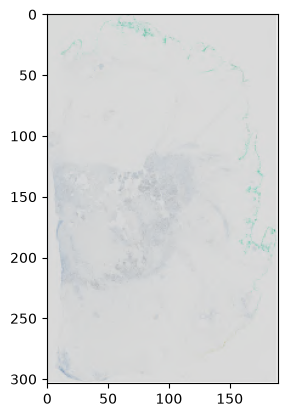

In [11]:
# visualize a thumbnail
plt.imshow(he_wsi_vsi[1][-1][:])

## Efficiency over alternative readers for repeated image access

When using vision models to embed image patches, due to memory constraint, it's often undesirable to first decompress and load the entire image into memory. Rather, tile generator that iteratively load (overlapping) image regions can be used to reduce memory usage and increase efficiency by using multiple workers to load in parallel. For TIFF-like files, `ezslide` employs smart caching strategy to be faster and more memory efficient (on repeated access) than alternatives from `openslide` for example, as shown in the following experiment using an example WSI:

In [ ]:
import time
import tracemalloc

import openslide

TILE_SIZE = 256
STRIDE = 128       # 50% overlap between neighboring tiles
REGION_SIZE = 1536 # crop of the level swept over


def sliding_window_tiles(height, width, tile_size, stride):
    """(y, x) top-left corners of overlapping tile_size x tile_size tiles
    that fit fully within (height, width)."""
    ys = range(0, height - tile_size + 1, stride)
    xs = range(0, width - tile_size + 1, stride)
    return [(y, x) for y in ys for x in xs]


coords = sliding_window_tiles(REGION_SIZE, REGION_SIZE, TILE_SIZE, STRIDE)
ez_level = he_wsi[0][1]  # pyramid level 1

os_slide = openslide.OpenSlide("../sample_images/example_he_wsi.svs")
os_level = min(range(os_slide.level_count),
              key=lambda i: abs(os_slide.level_dimensions[i][0] - ez_level.width))
os_downsample = os_slide.level_downsamples[os_level]

print(f"{len(coords)} overlapping {TILE_SIZE}x{TILE_SIZE} tiles "
     f"(stride {STRIDE}, {REGION_SIZE}x{REGION_SIZE} region)")
print(f"ezslide level 1: {ez_level.width}x{ez_level.height} -> "
     f"matched openslide level {os_level}: {os_slide.level_dimensions[os_level]}")

121 overlapping 256x256 tiles (stride 128, 1536x1536 region)
ezslide level 1: 3843x4374 -> matched openslide level 1: (3843, 4374)


In [13]:
def sweep_ezslide(level, coords, tile_size):
    for y, x in coords:
        np.asarray(level[y:y + tile_size, x:x + tile_size])


def sweep_openslide(slide, level, downsample, coords, tile_size):
    for y, x in coords:
        location = (int(x * downsample), int(y * downsample))
        np.asarray(slide.read_region(location, level, (tile_size, tile_size)))


def timed(fn, *args, **kwargs):
    """Elapsed seconds and peak traced memory (bytes) allocated during fn."""
    tracemalloc.start()
    start = time.perf_counter()
    fn(*args, **kwargs)
    elapsed = time.perf_counter() - start
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return elapsed, peak


# Each reader sweeps the same overlapping tiles twice without reopening the
# file, so the second sweep is a cache-warm replay of the first.
ez_cold, ez_cold_peak = timed(sweep_ezslide, ez_level, coords, TILE_SIZE)
ez_warm, ez_warm_peak = timed(sweep_ezslide, ez_level, coords, TILE_SIZE)

os_cold, os_cold_peak = timed(sweep_openslide, os_slide, os_level, os_downsample, coords, TILE_SIZE)
os_warm, os_warm_peak = timed(sweep_openslide, os_slide, os_level, os_downsample, coords, TILE_SIZE)

print(f"{'reader':<12}{'cold (s)':>10}{'warm (s)':>10}{'warm speedup':>14}"
     f"{'cold peak MB':>14}{'warm peak MB':>14}")
print(f"{'ezslide':<12}{ez_cold:>10.3f}{ez_warm:>10.3f}{ez_cold / ez_warm:>13.2f}x"
     f"{ez_cold_peak / 2**20:>14.2f}{ez_warm_peak / 2**20:>14.2f}")
print(f"{'openslide':<12}{os_cold:>10.3f}{os_warm:>10.3f}{os_cold / os_warm:>13.2f}x"
     f"{os_cold_peak / 2**20:>14.2f}{os_warm_peak / 2**20:>14.2f}")

reader        cold (s)  warm (s)  warm speedup  cold peak MB  warm peak MB
ezslide          0.485     0.032        15.37x          7.23          0.01
openslide        0.869     0.708         1.23x          0.75          0.75


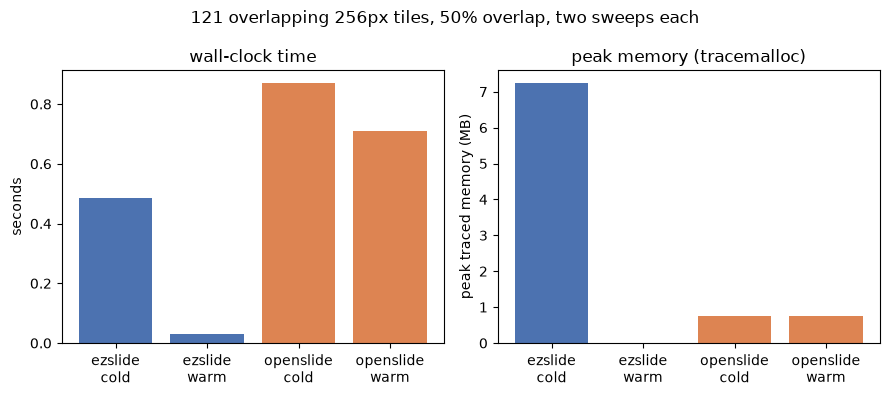

In [14]:
labels = ['ezslide\ncold', 'ezslide\nwarm', 'openslide\ncold', 'openslide\nwarm']
times = [ez_cold, ez_warm, os_cold, os_warm]
peaks_mb = [p / 2**20 for p in (ez_cold_peak, ez_warm_peak, os_cold_peak, os_warm_peak)]
colors = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']

fig, (ax_time, ax_mem) = plt.subplots(1, 2, figsize=(9, 4))
ax_time.bar(labels, times, color=colors)
ax_time.set_ylabel('seconds')
ax_time.set_title('wall-clock time')

ax_mem.bar(labels, peaks_mb, color=colors)
ax_mem.set_ylabel('peak traced memory (MB)')
ax_mem.set_title('peak memory (tracemalloc)')

fig.suptitle(f'{len(coords)} overlapping {TILE_SIZE}px tiles, 50% overlap, two sweeps each')
fig.tight_layout()
plt.show()

# Integration with `wsidata`

Sometimes we want to not just read but also process the WSIs and attach metadata or annotations to it, this requires more complex data model than the basic image readers as shown above. We choose to integrate with `wsidata` that builds upon `spatialdata`, which enables using other packages in the spatial biology ecosystem like `lazyslide` to process the images.

First, import `wsidata`, and let `ezslide` register the new image readers so `wsidata` can use them.

In [16]:
import wsidata
ezslide.register_readers() 

print(wsidata.READERS)

/n/scratch/users/z/ziz531/ezslide/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


openslide  (✓ Available)
tifffile_zarr  (✓ Available)
tifffile_zarr_pyramid  (✓ Available)
vsi_zarr  (✓ Available)
bioformats  (✗ Not Installed)
cucim  (✗ Not Installed)
fastslide  (✗ Not Installed)
isyntax  (✗ Not Installed)
pylibczi  (✗ Not Installed)
tiffslide  (✗ Not Installed)


WSI: ../sample_images/example_he_wsi.svs
Reader: tifffile_zarr
Dimensions: 17497×15374 (h×w), 3 Pyramids
Pixel physical size: 0.24980000000000002 MPP
SpatialData object
└── Images
      └── 'wsi': DataTree[cyx] (3, 17497, 15374), (3, 4374, 3843), (3, 2187, 1921)
with coordinate systems:
    ▸ 'global'
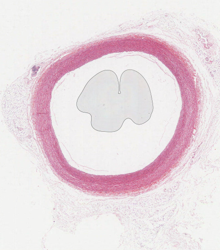

In [17]:
wsi = wsidata.open_wsi("../sample_images/example_he_wsi.svs", 
                       attach_images=True, reader="tifffile_zarr")
wsi

Note we can now use convenience functions from `wsidata` such as for accessing image region directly.

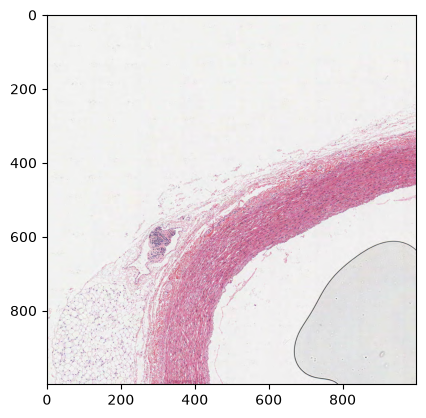

In [18]:
plt.imshow(wsi.read_region(0, 0, 1000, 1000, level=2))

## Reading images with arbitrary number of channels

In my lab, multiplexed imaging with CyCIF protocol routinely generates large image datasets with up to ~50 channels which is now supported by `ezslide` but not natively by `wsidata` (which assumes `SYX` or `YXS` axis orders). Here we demonstrate loading an example multichannel image generated using Bio-Formats. Note, the image by chance have 3 channels but is correctly parsed (not treated as RGB), and the thumbnail shows only the first channel.

In [19]:
!curl -o "../sample_images/example_fluor_image.ome.tif" "https://downloads.openmicroscopy.org/images/OME-TIFF/2016-06/bioformats-artificial/multi-channel.ome.tif"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0


  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0


100  221k  100  221k    0     0   322k      0 --:--:-- --:--:-- --:--:--  322k


WSI: ../sample_images/example_fluor_image.ome.tif
Reader: tifffile_zarr
Dimensions: 167×439 (h×w), 1 Pyramid
Pixel physical size: None MPP
SpatialData object
└── Images
      └── 'wsi': DataTree[cyx] (3, 167, 439)
with coordinate systems:
    ▸ 'global'
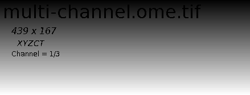

In [20]:
multi_channel_image = wsidata.open_wsi("../sample_images/example_fluor_image.ome.tif",
                                        attach_images=True, reader="tifffile_zarr")
multi_channel_image

# Saving images to OME-TIFF format

Raw images from various scanners often have awkward chunk sizes (some are even banded instead of chunked!). Also, sometimes we may want to build pyramid or compress data further before viewing them. In these cases, an initial conversion to OME-TIFF format is necessary, and `ezslide` provides a versatile tool at `ezslide convert` that can handle these cases and more.

In [21]:
!ezslide convert

usage: ezslide convert [-h] [--tile-size PIXELS] [--compression COMPRESSION]
                       [--levels N] [--no-pyramid] [--downsample MODE]
                       [--mask] [--split-rgb]
                       [--channel-names NAME [NAME ...]]
                       [--pixel-size MICRONS] [--name NAME] [--scene N]
                       [--max-mem BYTES] [--num-threads N] [--overwrite]
                       INPUT [INPUT ...] OUTPUT.ome.tif
ezslide convert: error: the following arguments are required: INPUT, OUTPUT.ome.tif
